In [57]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

In [58]:
# Load NHGIS block data
nhgis = pd.read_csv("nhgis0002_ds258_2020_block.csv", dtype=str)

# Keep only what we need
nhgis = nhgis[[
    "GEOCODE",        # Block GEOID
    "COUNTYA",        # County id
    "INTPTLAT",       # centroid lat
    "INTPTLON",       # centroid lon
    "U7H001"          # population
]].copy()

# Rename to consistent names
nhgis.rename(columns={
    "GEOCODE": "BLOCK_GEOID20",
    "U7H001": "population"
}, inplace=True)

# Convert numeric fields
nhgis["population"] = nhgis["population"].astype(float)

# INTPTLAT / INTPTLON are strings like "+42.6692483"
nhgis["INTPTLAT"] = nhgis["INTPTLAT"].astype(float)
nhgis["INTPTLON"] = nhgis["INTPTLON"].astype(float)

# IMPORTANT: from_xy(LON, LAT)
gdf_blocks = gpd.GeoDataFrame(
    nhgis,
    geometry=gpd.points_from_xy(
        nhgis["INTPTLON"],
        nhgis["INTPTLAT"]
    ),
    crs="EPSG:4326"
)

# Project for distance calculations
gdf_blocks = gdf_blocks.to_crs(32618)

# Tompkins = 36109, Schuyler = 36097
gdf_blocks = gdf_blocks[
    gdf_blocks["BLOCK_GEOID20"].str.startswith(("36109", "36097"))
].reset_index(drop=True)

In [59]:
SCHUYLER_POVERTY_RATE = 0.151  
TOMPKINS_POVERTY_RATE = 0.165
PANTRY_UTILIZATION = 0.365

In [60]:
# gdf_blocks["county_fips"] = gdf_blocks["BLOCK_GEOID20"].str[2:5]
def assign_poverty(row):
    if row["COUNTYA"] == "109":   # Tompkins
        return TOMPKINS_POVERTY_RATE
    elif row["COUNTYA"] == "097": # Schuyler
        return SCHUYLER_POVERTY_RATE
    else:
        return np.nan

gdf_blocks["poverty_frac_final"] = gdf_blocks.apply(assign_poverty, axis=1)
gdf_blocks["pantry_users"] = gdf_blocks["population"] * gdf_blocks["poverty_frac_final"] * PANTRY_UTILIZATION
gdf_blocks_new = gdf_blocks.copy()
gdf_blocks_old = gdf_blocks.copy()

In [61]:
gdf_blocks.head()

,BLOCK_GEOID20,COUNTYA,INTPTLAT,INTPTLON,population,geometry,poverty_frac_final,pantry_users
0,360979501001000,097,42.543094,-76.702852,11.0,POINT (360177.539 4711483.33),0.151,0.606265
1,360979501001001,097,42.542990,-76.714519,17.0,POINT (359219.302 4711491.06),0.151,0.936955
2,360979501001002,097,42.540524,-76.723426,40.0,POINT (358482.376 4711232.122),0.151,2.204600
3,360979501001003,097,42.538836,-76.730203,5.0,POINT (357922.053 4711056.012),0.151,0.275575
4,360979501001004,097,42.541794,-76.740613,3.0,POINT (357073.922 4711401.946),0.151,0.165345


In [62]:
gdf_blocks["pantry_users"].sum()

np.float64(7354.639770000001)

In [63]:
pantries_new = pd.read_csv("data/pantries_new_hours.csv")
gdf_pantry_new = gpd.GeoDataFrame(pantries_new,geometry=gpd.points_from_xy(pantries_new.Long, pantries_new.Lat),crs="EPSG:4326").to_crs(32618)
pantry_ids_new = gdf_pantry_new["Pantry"].tolist()

pantries_old = pd.read_csv("data/pantries_old_hours.csv")
gdf_pantry_old = gpd.GeoDataFrame(pantries_old,geometry=gpd.points_from_xy(pantries_old.Long, pantries_old.Lat),crs="EPSG:4326").to_crs(32618)
pantry_ids_old = gdf_pantry_old["Pantry"].tolist()


In [64]:
decay_rate = 0.765  # 23.5% drop per mile

def decay(d_miles):
    return decay_rate ** d_miles

w1 = 2   # distance decay influence
w2 = 0.3   # hours open influence
w3 = 0.3    # days open influence

day_cols = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

def make_attraction(id,table,base):
    max_hours = 12
    max_distance = 10  # miles

    for pid in id:
        pantry_row = table.loc[table["Pantry"] == pid].iloc[0]
        pantry_point = pantry_row.geometry
        
        distances = base.geometry.distance(pantry_point) / 1609.34 # distance in miles from each block to this pantry
        D_ij = decay(distances) # distance decay
        D_ij[distances > max_distance] = 0

        row_days = pantry_row[day_cols]
        hours = np.sum(row_days)
        days_open = (row_days > 0).sum()

        hours_norm = hours / max_hours
        days_norm = days_open / 7

        # attractiveness
        base[f"A_{pid}"] = D_ij * (w1 + w2 * hours_norm + w3 * days_norm) #may want to sqrt or log hours later -> diminishing returns
        
make_attraction(pantry_ids_new,gdf_pantry_new,gdf_blocks_new)
make_attraction(pantry_ids_old,gdf_pantry_old,gdf_blocks_old)


In [65]:
def normalize(ids, base):
    A_cols = [f"A_{pid}" for pid in ids]
    A_sum = base[A_cols].sum(axis=1)

    for pid in ids:
        base[f"P_{pid}"] = np.where(A_sum > 0, base[f"A_{pid}"] / A_sum, 0)


normalize(pantry_ids_new,gdf_blocks_new)
normalize(pantry_ids_old,gdf_blocks_old)

In [66]:
def demand(ids, base):
    P_cols = [f"P_{pid}" for pid in ids]

    base["first_pantry"]  = base[P_cols].idxmax(axis=1)
    base["second_pantry"] = base[P_cols].apply(lambda row: row.nlargest(2).index[-1], axis=1)
    base["third_pantry"]  = base[P_cols].apply(lambda row: row.nlargest(3).index[-1], axis=1)

    for pid in ids:
        base[f"demand_{pid}"] = np.zeros(len(base))

        mask1 = base["first_pantry"] == f"P_{pid}"
        mask2 = base["second_pantry"] == f"P_{pid}"
        mask3 = base["third_pantry"] == f"P_{pid}"

        base.loc[mask1, f"demand_{pid}"] += base.loc[mask1, "pantry_users"]
        base.loc[mask2, f"demand_{pid}"] += 0.2 * base.loc[mask2, "pantry_users"] #20% go to exactly 2 pantries
        base.loc[mask3, f"demand_{pid}"] += 0.1 * base.loc[mask3, "pantry_users"] #10% go to 3 pantries

In [67]:
# def demand(id,base):
#     P_cols = [f"P_{pid}" for pid in id]

#     w1 = 1.0
#     w2 = 0.4
#     w3 = 0.2

#     base["first_prob_value"]  = base[P_cols].max(axis=1)
#     base["second_prob_value"] = base[P_cols].apply(lambda row: row.nlargest(2).iloc[-1], axis=1)
#     base["third_prob_value"] = base[P_cols].apply(lambda row: row.nlargest(3).iloc[-1], axis=1)

#     base["first_pantry"]  = base[P_cols].idxmax(axis=1)
#     base["second_pantry"] = base[P_cols].apply(lambda row: row.nlargest(2).index[-1], axis=1)
#     base["third_pantry"]  = base[P_cols].apply(lambda row: row.nlargest(3).index[-1], axis=1)

#     for pid in id:
#         D1 = base.apply(lambda row: row["first_prob_value"]  if row["first_pantry"]  == f"P_{pid}" else 0, axis=1)
#         D2 = base.apply(lambda row: row["second_prob_value"] if row["second_pantry"] == f"P_{pid}" else 0, axis=1)
#         D3 = base.apply(lambda row: row["third_prob_value"]  if row["third_pantry"]  == f"P_{pid}" else 0, axis=1)
        
#         base[f"demand_{pid}"] = (
#             base["pantry_users"] * (w1*D1 + w2*D2 + w3*D3)
#         )

demand(pantry_ids_new,gdf_blocks_new)
demand(pantry_ids_old,gdf_blocks_old)

In [68]:
total = 0
for pid in pantry_ids_new:
    total += gdf_blocks_new[f"demand_{pid}"].sum()
print(total)
    

9561.031701


In [69]:
total_users = gdf_blocks_new["pantry_users"].sum()
total_demand = sum(gdf_blocks_new[f"demand_{pid}"].sum() for pid in pantry_ids_new)

print("users =", total_users)
print("demand =", total_demand)
print("expected demand =", 1.3 * total_users)

users = 7354.639770000001
demand = 9561.031701
expected demand = 9561.031701000002


In [70]:
pantry_demand_new = {
    pid: gdf_blocks_new[f"demand_{pid}"].sum()
    for pid in pantry_ids_new
}
pantry_demand_old = {
    pid: gdf_blocks_old[f"demand_{pid}"].sum()
    for pid in pantry_ids_old
}

print(f"Demands with new location: ", pantry_demand_new)
print(f"Demands with old location: ", pantry_demand_old)

Demands with new location:  {'New Enfield Food Distribution': np.float64(1123.7701759999998), 'School Food Center - Enfield Elementary': np.float64(748.6177009999999), 'Newfield Kitchen Cupboard': np.float64(495.4217635), 'Ithaca Kitchen Cupboard': np.float64(23.812965000000002), 'Immaculate Conception Food Pantry': np.float64(0.0), 'Loaves & Fishes of Tompkins County': np.float64(12.845992500000001), 'The Salvation Army - Ithaca': np.float64(0.0), 'REACH Medical': np.float64(1644.0581849999999), 'Greater Ithaca Activities Center (GIAC)': np.float64(2055.6418575000002), 'Southside Community Center': np.float64(31.600057500000005), "Prunty's Pantry (Ithaca College Food Pantry)": np.float64(399.5507175), 'Baptized Church of Jesus Christ Food Pantry': np.float64(0.8371275), 'NML Food Giveaway (No Mas Lagrimas)': np.float64(0.0), 'Cornell Food Pantry': np.float64(163.43860500000002), 'School Food Center - Ithaca High School (Community Closet)': np.float64(35.48457), 'Tompkins Community Act

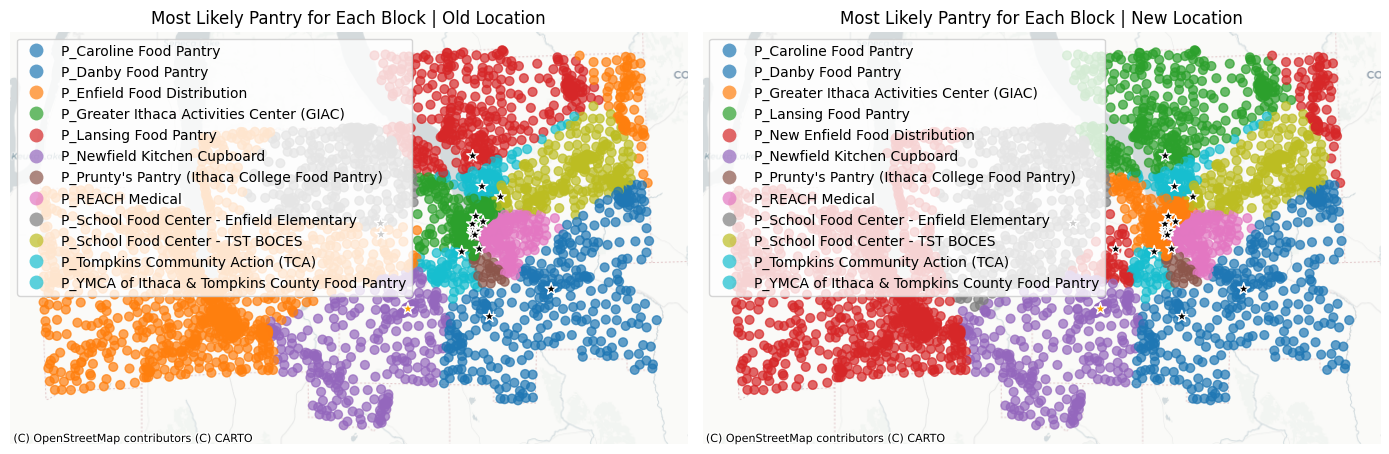

In [71]:
# Reproject to Web Mercator for contextily
gdf_blocks_new_3857 = gdf_blocks_new.to_crs(epsg=3857)
gdf_blocks_old_3857 = gdf_blocks_old.to_crs(epsg=3857)
gdf_pantry_new_3857 = gdf_pantry_new.to_crs(epsg=3857)
gdf_pantry_old_3857 = gdf_pantry_old.to_crs(epsg=3857)

# Assign best pantry
gdf_blocks_new_3857["best_pantry"] = gdf_blocks_new_3857[[f"P_{pid}" for pid in pantry_ids_new]].idxmax(axis=1)
gdf_blocks_old_3857["best_pantry"] = gdf_blocks_old_3857[[f"P_{pid}" for pid in pantry_ids_old]].idxmax(axis=1)

# --- SORT OLD ---
sorted_items_old = sorted(pantry_demand_old.items(), key=lambda kv: kv[1], reverse=True)
pantry_names_old = [name for name, val in sorted_items_old]
demand_values_old = [val for name, val in sorted_items_old]

# --- SORT NEW ---
sorted_items_new = sorted(pantry_demand_new.items(), key=lambda kv: kv[1], reverse=True)
pantry_names_new = [name for name, val in sorted_items_new]
demand_values_new = [val for name, val in sorted_items_new]

# Highlight targets
highlight_name1 = "Enfield Food Distribution"
highlight_name2 = "New Enfield Food Distribution"

# --- COLORS OLD ---
colors_old = [
    "orange" if name == highlight_name1 else "black"
    for name in pantry_names_old
]

# --- COLORS NEW ---
colors_new = [
    "orange" if name == highlight_name2 else "black"
    for name in pantry_names_new
]

# Create side-by-side figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- OLD LOCATION MAP ---
gdf_blocks_old_3857.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    ax=ax1,
    alpha=0.7,
    zorder=2,
    markersize=40,
)
gdf_pantry_old_3857.plot(
    ax=ax1,
    marker="*",
    color=colors_old,
    markersize=80,
    edgecolor="white",
    zorder=3
)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron, zoom='auto')
ax1.set_title("Most Likely Pantry for Each Block | Old Location")
ax1.set_axis_off()

# --- NEW LOCATION MAP ---
gdf_blocks_new_3857.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    ax=ax2,
    alpha=0.7,
    zorder=2,
    markersize=40,
)
gdf_pantry_new_3857.plot(
    ax=ax2,
    marker="*",
    color=colors_new,
    markersize=80,
    edgecolor="white",
    zorder=3
)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron, zoom='auto')
ax2.set_title("Most Likely Pantry for Each Block | New Location")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

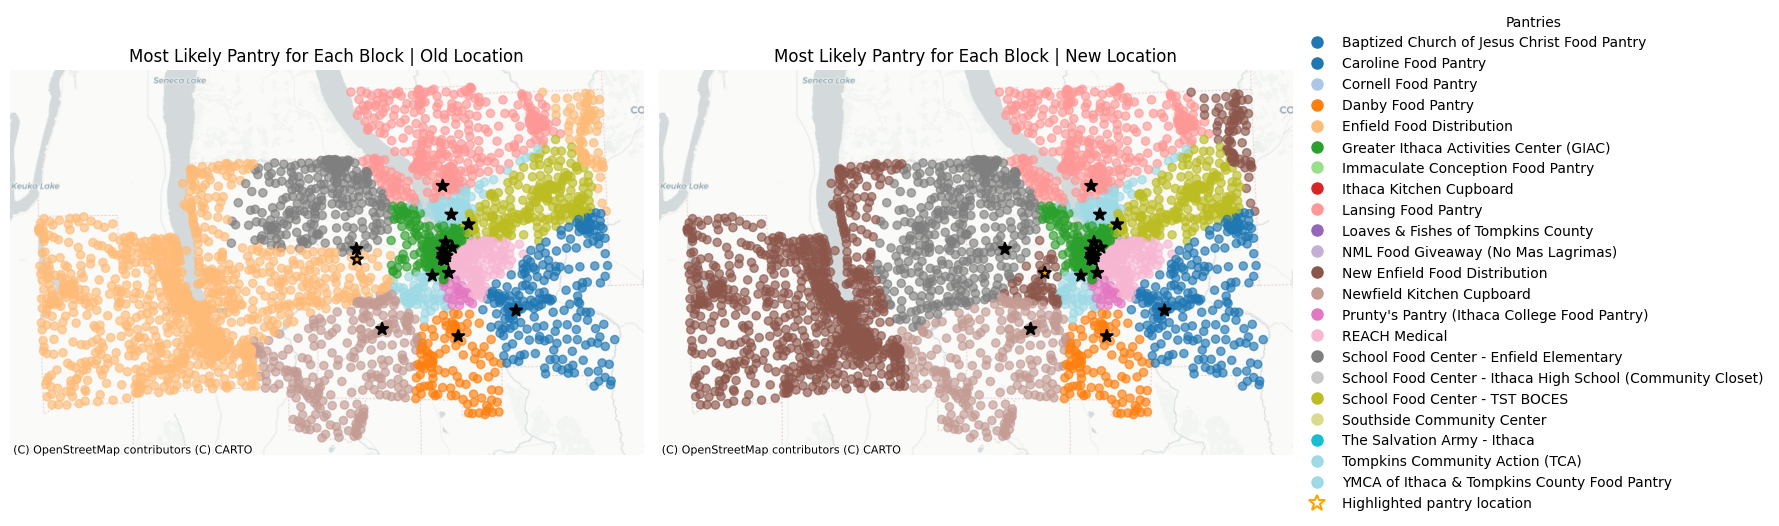

In [79]:
# Reproject to Web Mercator for basemap
gdf_blocks_new_3857 = gdf_blocks_new.to_crs(epsg=3857).copy()
gdf_blocks_old_3857 = gdf_blocks_old.to_crs(epsg=3857).copy()
gdf_pantry_new_3857 = gdf_pantry_new.to_crs(epsg=3857).copy()
gdf_pantry_old_3857 = gdf_pantry_old.to_crs(epsg=3857).copy()

# Assign best pantry
gdf_blocks_new_3857["best_pantry"] = gdf_blocks_new_3857[[f"P_{pid}" for pid in pantry_ids_new]].idxmax(axis=1)
gdf_blocks_old_3857["best_pantry"] = gdf_blocks_old_3857[[f"P_{pid}" for pid in pantry_ids_old]].idxmax(axis=1)

# Remove the "P_" prefix so labels match pantry names
gdf_blocks_new_3857["best_pantry"] = gdf_blocks_new_3857["best_pantry"].str.replace("P_", "", regex=False)
gdf_blocks_old_3857["best_pantry"] = gdf_blocks_old_3857["best_pantry"].str.replace("P_", "", regex=False)

# -------------------------------------------------------------------
# Create ONE shared color mapping for all pantry names across both maps
# -------------------------------------------------------------------
all_pantries = sorted(set(pantry_ids_old) | set(pantry_ids_new))

# Use a colormap with enough distinct colors
cmap = plt.get_cmap("tab20", len(all_pantries))
color_dict = {pantry: cmap(i) for i, pantry in enumerate(all_pantries)}

# Color each block by its assigned best pantry
gdf_blocks_old_3857["color"] = gdf_blocks_old_3857["best_pantry"].map(color_dict)
gdf_blocks_new_3857["color"] = gdf_blocks_new_3857["best_pantry"].map(color_dict)

# Color each pantry star using the same mapping
gdf_pantry_old_3857["color"] = gdf_pantry_old_3857["Pantry"].map(color_dict)
gdf_pantry_new_3857["color"] = gdf_pantry_new_3857["Pantry"].map(color_dict)

# Optional: highlight the moved pantry with a special edge
highlight_old = "Enfield Food Distribution"
highlight_new = "New Enfield Food Distribution"

# -------------------
# Plot side-by-side map
# -------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# OLD LOCATION
gdf_blocks_old_3857.plot(
    ax=ax1,
    color=gdf_blocks_old_3857["color"],
    alpha=0.65,
    markersize=35,
    zorder=2
)

gdf_pantry_old_3857.plot(
    ax=ax1,
    marker="*",
    color=[
        "orange" if name == highlight_old else "black"
        for name in gdf_pantry_old_3857["Pantry"]
    ],
    markersize=80,
    edgecolor="black",
    linewidth=1.5,
    zorder=3
)

ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ax1.set_title("Most Likely Pantry for Each Block | Old Location")
ax1.set_axis_off()

# NEW LOCATION
gdf_blocks_new_3857.plot(
    ax=ax2,
    color=gdf_blocks_new_3857["color"],
    alpha=0.65,
    markersize=35,
    zorder=2
)

gdf_pantry_new_3857.plot(
    ax=ax2,
    marker="*",
    color=[
        "orange" if name == highlight_new else "black"
        for name in gdf_pantry_new_3857["Pantry"]
    ],
    markersize=80,
    edgecolor="black",
    linewidth=1.5,
    zorder=3
)

ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)
ax2.set_title("Most Likely Pantry for Each Block | New Location")
ax2.set_axis_off()

# -------------------
# One shared legend
# -------------------
legend_handles = [
    mlines.Line2D(
        [], [], 
        color=color_dict[pantry],
        marker='o',
        linestyle='None',
        markersize=8,
        label=pantry
    )
    for pantry in all_pantries
]

# Optional extra legend item for moved pantry highlight
legend_handles.append(
    mlines.Line2D(
        [], [],
        color='white',
        marker='*',
        markeredgecolor='orange',
        markeredgewidth=1.5,
        linestyle='None',
        markersize=12,
        label='Highlighted pantry location'
    )
)

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.81, 0.5),
    frameon=False,
    title="Pantries"
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

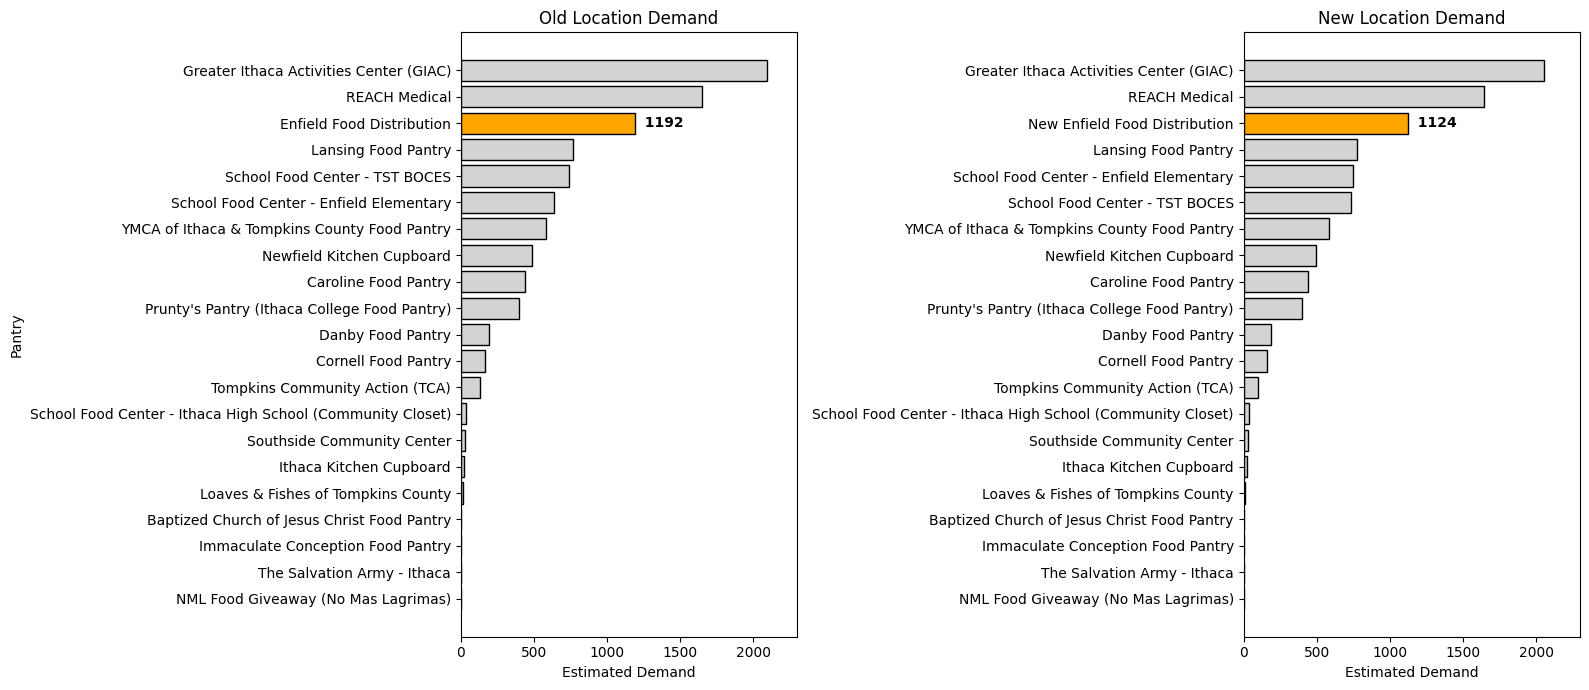

In [73]:
# --- SORT OLD ---
sorted_items_old = sorted(pantry_demand_old.items(), key=lambda kv: kv[1], reverse=True)
pantry_names_old = [name for name, val in sorted_items_old]
demand_values_old = [val for name, val in sorted_items_old]

# --- SORT NEW ---
sorted_items_new = sorted(pantry_demand_new.items(), key=lambda kv: kv[1], reverse=True)
pantry_names_new = [name for name, val in sorted_items_new]
demand_values_new = [val for name, val in sorted_items_new]

# Highlight targets
highlight_name1 = "Enfield Food Distribution"
highlight_name2 = "New Enfield Food Distribution"

# --- COLORS OLD ---
colors_old = [
    "orange" if name == highlight_name1 else "lightgray"
    for name in pantry_names_old
]

# --- COLORS NEW ---
colors_new = [
    "orange" if name == highlight_name2 else "lightgray"
    for name in pantry_names_new
]

# --- CREATE SIDE-BY-SIDE FIGURE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# ----- OLD (LEFT) -----
ax1.barh(pantry_names_old, demand_values_old, color=colors_old, edgecolor="black")
ax1.set_title(f"Old Location Demand")
ax1.set_xlabel("Estimated Demand")
ax1.set_ylabel("Pantry")
ax1.invert_yaxis()

# ----- NEW (RIGHT) -----
ax2.barh(pantry_names_new, demand_values_new, color=colors_new, edgecolor="black")
ax2.set_title(f"New Location Demand")
ax2.set_xlabel("Estimated Demand")
ax2.invert_yaxis()

# --- OPTIONAL: REMOVE Y-LABELS ON RIGHT TO REDUCE CLUTTER ---
ax2.set_ylabel("")

# --- OPTIONAL: FORCE SAME X SCALE FOR FAIR COMPARISON ---
max_val = max(max(demand_values_old), max(demand_values_new))
ax1.set_xlim(0, max_val * 1.1)
ax2.set_xlim(0, max_val * 1.1)

for ax, names, values in [(ax1, pantry_names_old, demand_values_old),
                          (ax2, pantry_names_new, demand_values_new)]:
    for i, (name, val) in enumerate(zip(names, values)):
        if name in [highlight_name1, highlight_name2]:
            ax.text(val, i, f"  {val:.0f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()
